In [163]:
import pandas as pd
from openai import OpenAI
from palmerpenguins import load_penguins
import re
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [164]:
# Setting up connection to LM Studio

client = OpenAI (
    base_url='http://localhost:1234/v1',
    api_key='lm_studio' 
)

In [165]:
# Loading data

penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [204]:
# Building function to prompt model with preprogrammed context, and extract and run code

context = f'''
<role>
You are an expert data science assistant helping analyze a pandas dataframe.
</role>

<context>
The dataframe is called `penguins` and is already loaded.

<columns>
{penguins.dtypes}
</columns>

<sample_data>
{penguins.head(3).to_string()}
</sample_data>
</context>

<format>
Always return code in a ```python code block.
</format>

<constraints>
Use only these libraries: pandas as pd, seaborn as sns, matplotlib.pyplot as plt, and sklearn.
Always use the variable name `penguins`. Never rename it.
Do not include import statements in your code. Never import libraries. All necessary libraries are already imported.
</constraints>
'''

def q(prompt):

    # Sending requests to Gemma via local LM Studio API
    response = client.chat.completions.create(
        model='google/gemma-3-12b', # Specifying model
        messages=[ # Establishing required conversation parameters
            {'role': 'system', 'content': context}, # Preprogrammed context
            {'role': 'user', 'content': f'<task>{prompt}</task>'} # User prompt wrapped in XML tags
        ],
        max_tokens=500 # Limiting length of response
    )
    result = response.choices[0].message.content # Extracting text from API response object
    code_blocks = re.findall(r'```python(.*?)```', result, re.DOTALL) # Isolating the Python code using regex
    
    if code_blocks: # Checking if there is any code
        for code in code_blocks: # Looping through the extracted code
            display(Markdown(f'```python{code}```')) # Showing the code to be run
            get_ipython().run_cell(code.strip()) # Running the code
    else: 
        display(Markdown(result)) # Showing the whole response as markdown in the absence of detectable code

# Running some test prompts

In [167]:
q('Which pandas functions are most useful for analyzing this dataset?')

Here's a breakdown of pandas functions that would be particularly useful for analyzing the `penguins` dataset, categorized by their purpose:

**1. Data Exploration & Inspection:**

*   `penguins.head()` / `penguins.tail()`:  Quickly view the first/last few rows to get a sense of the data.
*   `penguins.info()`:  Crucial for understanding data types, non-null counts (missing values), and memory usage.
*   `penguins.describe()`:  Provides descriptive statistics (mean, std, min, max, quartiles) for numerical columns.
*   `penguins.describe(include=['object'])`:  Provides descriptive statistics for categorical (string) columns like 'species', 'island', and 'sex'.
*   `penguins.shape`:  Gives the dimensions (rows, columns) of the DataFrame.
*   `penguins.columns`:  Lists all column names.
*   `penguins.dtypes`: Shows the data type of each column.
*   `penguins.value_counts()`:  Counts the occurrences of unique values in a column (e.g., how many penguins are of each species).  Very useful for categorical variables.
*   `penguins.isnull().sum()`: Checks for missing values in each column and returns the count of nulls.

**2. Data Cleaning & Transformation:**

*   `penguins.dropna()`: Removes rows with missing values (use cautiously!).
*   `penguins.fillna(value)`:  Fills missing values with a specified value (e.g., the mean of a column).
*   `penguins['column_name'].astype(new_dtype)`:  Changes the data type of a column (e.g., converting a string representation of numbers to numeric types).
*   `penguins.rename(columns={'old_name': 'new_name'})`: Renames columns.

**3. Data Selection & Filtering:**

*   `penguins['column_name']`:  Selects a single column as a Series.
*   `penguins[['column1', 'column2']]`: Selects multiple columns as a DataFrame.
*   `penguins[penguins['column_name'] == value]`: Filters rows based on a condition (e.g.,

```python
sns.countplot(x='species', data=penguins)
plt.show()
```

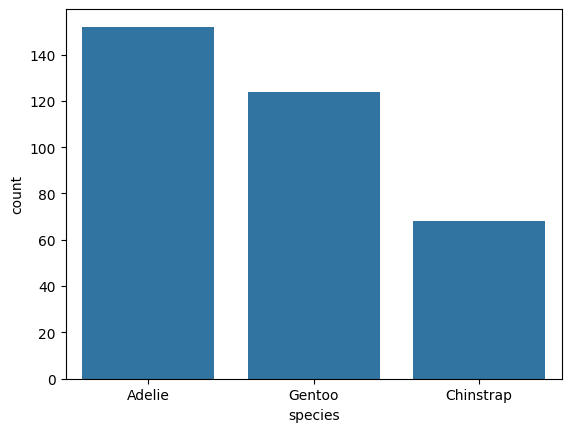

In [168]:
q('bar graph of count for each species')

```python
penguins.hist(column='flipper_length_mm', bins=10)
```

array([[<Axes: title={'center': 'flipper_length_mm'}>]], dtype=object)

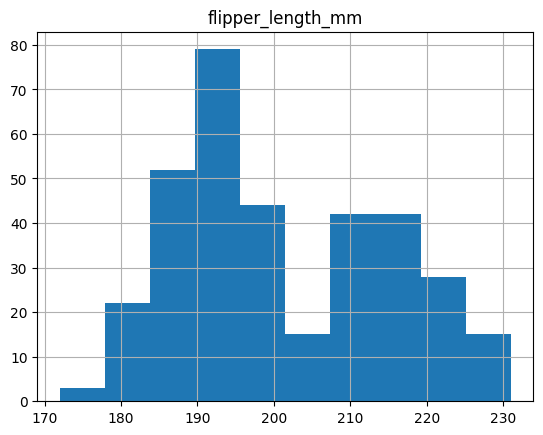

In [169]:
q('histogram of flipper length')

In [170]:
q('average body mass')

```python
print(penguins['body_mass_g'].mean())
```

4201.754385964912


In [171]:
q('summary statistics for bill depth')

```python
penguins['bill_depth_mm'].describe()
```

count    342.000000
mean      17.151170
std        1.974793
min       13.100000
25%       15.600000
50%       17.300000
75%       18.700000
max       21.500000
Name: bill_depth_mm, dtype: float64

In [172]:
q('summary statistics for bill depth by species')

```python
penguins_bill_depth_by_species = penguins.groupby('species')['bill_depth_mm'].describe()
print(penguins_bill_depth_by_species)
```

           count       mean       std   min   25%    50%   75%   max
species                                                             
Adelie     151.0  18.346358  1.216650  15.5  17.5  18.40  19.0  21.5
Chinstrap   68.0  18.420588  1.135395  16.4  17.5  18.45  19.4  20.8
Gentoo     123.0  14.982114  0.981220  13.1  14.2  15.00  15.7  17.3


In [173]:
q('how are the species distributed among the different islands?')

```python
island_counts = penguins.groupby('island')['species'].value_counts()
print(island_counts)
```

island     species  
Biscoe     Gentoo       124
           Adelie        44
Dream      Chinstrap     68
           Adelie        56
Torgersen  Adelie        52
Name: count, dtype: int64


```python
sns.countplot(x='island', hue='species', data=penguins)
plt.show()
```

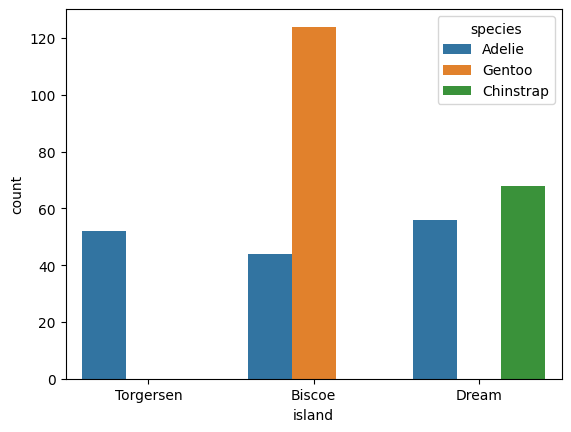

In [174]:
q('visualize the distribution of species among the different islands')

In [192]:
q('create a new column called species_encoded by encoding the species column')

```python
penguins['species_encoded'] = penguins['species'].astype('category').cat.codes
```

In [193]:
q('create a variable called num_var that is a list of the names of the numerical columns')

```python
num_var = [col for col in penguins.columns if pd.api.types.is_numeric_dtype(penguins[col])]
```

In [195]:
num_var

['bill_length_mm',
 'bill_depth_mm',
 'flipper_length_mm',
 'body_mass_g',
 'year',
 'species_encoded']

In [205]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
 8   species_encoded    344 non-null    int8   
dtypes: float64(4), int64(1), int8(1), str(3)
memory usage: 22.0 KB


```python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics

num_var = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

correlation_matrix = penguins[num_var].corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()
```

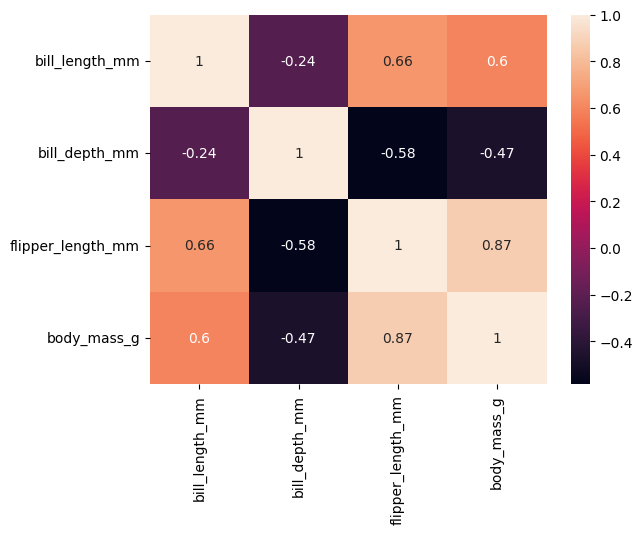

In [207]:
q('num_var is a list of the numerical variables. It is already defined. Use it to create a correlation matrix of the numerical variables.')

In [201]:
q('''Create a correlation matrix of the numerical variables as a heatmap.
  A variable named num_var is already defined. It is a list of the numerical variables. 
  Use num_var to specify the numerical subset of penguins. 
  Include int8, int64, and float64.
  Do not define the variable num_var. It is already defined.
  Remember, do not import any libraries.''')

```python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

num_var = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year']

correlation_matrix = penguins[num_var].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.show()
```

ImportError: cannot import name 'LogisticRegression' from 'sklearn.ensemble' (/Users/mattomalley/projects/palmer-penguins/.venv/lib/python3.12/site-packages/sklearn/ensemble/__init__.py)

In [191]:
num_var

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year']

```python
sns.scatterplot(x="body_mass_g", y="flipper_length_mm", hue="species", data=penguins)
plt.show()
```

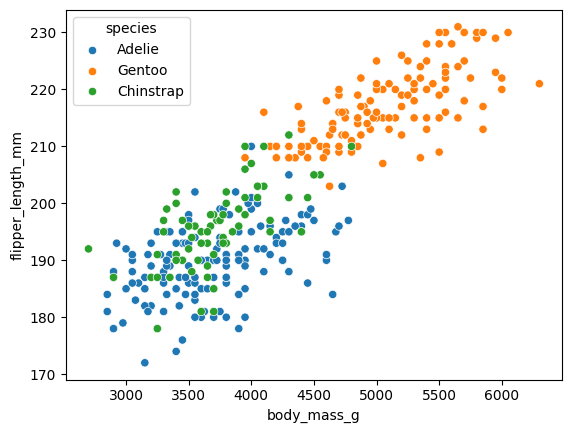

In [180]:
q('create a scatterplot of body mass against flipper length with species as hue')

# Predictive Modeling

In [181]:
num_var.remove('year')
num_var

['bill_length_mm',
 'bill_depth_mm',
 'flipper_length_mm',
 'body_mass_g',
 'species_encoded']

In [182]:
# Splititng dataset

features = num_var
features.remove('species_encoded')

q('There is a variable called features that is a list of the columns to use for predictive modeling. Create the dataframe called X that is a subset of penguins using this list of columns')

```python
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins[features]
```

In [183]:
y = penguins['species_encoded']

In [184]:
q('X and y are already defined. Split X and y into train and test')

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
```

In [185]:
# Scaling

q(['StandardScaler is already imported. X_train is already defined. Scale X_train.'])

```python
X_train = StandardScaler().fit_transform(X_train)
```